<a href="https://colab.research.google.com/github/tikadatta2005/CSC60904-Deep-Learning-T3/blob/main/Utsab_4CNN_4Pooling_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# IMPORTS AND REPOSITORY SETUP
# ============================================================

import os

repo_url = "https://github.com/tikadatta2005/CSC60904-Deep-Learning-T3.git"
repo_dir = "CSC60904-Deep-Learning-T3"

if not os.path.exists(repo_dir):
    !git clone {repo_url}

os.chdir(repo_dir)

!pip install -q scikit-learn seaborn matplotlib pandas

print("Repository ready.")

Cloning into 'CSC60904-Deep-Learning-T3'...
remote: Enumerating objects: 272, done.
remote: Counting objects: 100% (272/272), done.
remote: Compressing objects: 100% (204/204), done.
remote: Total 272 (delta 95), reused 230 (delta 53), pack-reused 0 (from 0)
Receiving objects: 100% (272/272), 4.48 MiB | 23.66 MiB/s, done.
Resolving deltas: 100% (95/95), done.
Repository ready.


In [ ]:
# ============================================================
# MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# DATASET PREPARATION
# ============================================================

import zipfile
import shutil
import random
import uuid
from pathlib import Path

ZIP_PATH = "/content/drive/MyDrive/CSC60904_Projects/NSLv2.zip"

EXTRACT_PATH = "/content/NSLv2"

FINAL_PATH = "./datasets/final_dataset"

In [ ]:
# ============================================================
# CHECK WHETHER DATASET IS ALREADY PREPROCESSED
# ============================================================

def check_counts(path):

    expected = {
        "train":35100,
        "val":10800,
        "test":8100
    }

    for split in expected:

        split_path = Path(path)/split

        if not split_path.exists():
            return False

        count = sum(
            1 for f in split_path.rglob("*")
            if f.is_file()
        )

        if count != expected[split]:
            return False

    return True

In [ ]:
# ============================================================
# EXTRACT DATASET AND CREATE TRAIN / VAL / TEST
# ============================================================

if os.path.exists(FINAL_PATH) and check_counts(FINAL_PATH):

    print("Dataset already exists.")

else:

    if os.path.exists(FINAL_PATH):
        shutil.rmtree(FINAL_PATH)

    print("Extracting dataset...")

    if not os.path.exists(EXTRACT_PATH):

        with zipfile.ZipFile(ZIP_PATH,'r') as zip_ref:
            zip_ref.extractall(EXTRACT_PATH)

    random.seed(41)

    folders = [

        "क","ख","ग","घ","ङ",

        "च","छ","ज","झ","ञ",

        "ट","ठ","ड","ढ","ण",

        "त","थ","द","ध","न",

        "प","फ","ब","भ","म",

        "य","र","ल","व","श",

        "ष","स","ह","क्ष","त्र","ज्ञ"

    ]

    base = Path(FINAL_PATH)

    for folder in folders:

        (base/"train"/folder).mkdir(parents=True,exist_ok=True)

        (base/"val"/folder).mkdir(parents=True,exist_ok=True)

        (base/"test"/folder).mkdir(parents=True,exist_ok=True)

    data_root = Path(EXTRACT_PATH)/"NSLv2"/"data"

    if not (data_root/"Plain Background").exists():

        data_root = Path(EXTRACT_PATH)/"data"

        if not (data_root/"Plain Background").exists():

            possible = list(Path(EXTRACT_PATH).rglob("Plain Background"))

            if possible:
                data_root = possible[0].parent

    for index,name in enumerate(folders):

        plain = data_root/"Plain Background"/str(index)

        random_bg = data_root/"Random Background"/str(index)

        images = []

        if plain.exists():
            images.extend(list(plain.iterdir()))

        if random_bg.exists():
            images.extend(list(random_bg.iterdir()))

        if len(images)==0:
            continue

        random.shuffle(images)

        train_end = int(len(images)*0.65)

        val_end = int(len(images)*0.20)

        splits = {

            "train":images[:train_end],

            "val":images[train_end:train_end+val_end],

            "test":images[train_end+val_end:]

        }

        for split,file_list in splits.items():

            output = base/split/name

            for image in file_list:

                if image.is_file():

                    shutil.copy2(

                        image,

                        output/f"{uuid.uuid4()}-{uuid.uuid4()}-{name}.png"

                    )

    print("Dataset preprocessing complete.")

Extracting dataset...
Dataset preprocessing complete.


In [ ]:
# ============================================================
# IMPORT DEEP LEARNING LIBRARIES
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import pandas as pd

from torchvision import datasets
from torchvision import transforms

from torch.utils.data import DataLoader

from modules.architectures.Architecture import Architecture

from modules.helper.evaluator import evaluator

from modules.helper.calculate_metrics import calculate_metrics

from modules.helper.charts import gen_line_charts

In [ ]:
# ============================================================
# DATA LOADER (WITHOUT DATA AUGMENTATION)
# ============================================================

def get_dataloaders_no_aug(
    data_root="./datasets/final_dataset",
    batch_size=32,
    img_size=112
):

    root = Path(data_root)

    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
    ])

    train_ds = datasets.ImageFolder(root=root/"train", transform=transform)
    val_ds = datasets.ImageFolder(root=root/"val", transform=transform)
    test_ds = datasets.ImageFolder(root=root/"test", transform=transform)

    workers = 2 if torch.cuda.is_available() else 0

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=workers,
        pin_memory=torch.cuda.is_available()
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=workers,
        pin_memory=torch.cuda.is_available()
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=workers,
        pin_memory=torch.cuda.is_available()
    )

    print(f"Train : {len(train_ds)}")
    print(f"Validation : {len(val_ds)}")
    print(f"Test : {len(test_ds)}")

    return train_loader, val_loader, test_loader, train_ds.classes

In [ ]:
# ============================================================
# DATA LOADER (WITH DATA AUGMENTATION)
# ============================================================

def get_dataloaders_aug(
    data_root="./datasets/final_dataset",
    batch_size=32,
    img_size=112
):

    root = Path(data_root)

    # Augmentation only on the training split. Val/test stay on the plain
    # eval transform so comparisons against the non-augmented run are fair.
    train_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.9, 1.1)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
    ])

    eval_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
    ])

    train_ds = datasets.ImageFolder(root=root/"train", transform=train_transform)
    val_ds = datasets.ImageFolder(root=root/"val", transform=eval_transform)
    test_ds = datasets.ImageFolder(root=root/"test", transform=eval_transform)

    workers = 2 if torch.cuda.is_available() else 0

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=workers,
        pin_memory=torch.cuda.is_available()
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=workers,
        pin_memory=torch.cuda.is_available()
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=workers,
        pin_memory=torch.cuda.is_available()
    )

    print(f"Train : {len(train_ds)}")
    print(f"Validation : {len(val_ds)}")
    print(f"Test : {len(test_ds)}")

    return train_loader, val_loader, test_loader, train_ds.classes


In [ ]:
# ============================================================
# BUILD 4-LAYER CNN
# ============================================================

def build_custom_cnn(
    num_classes=36,
    in_channels=3
):

    model = Architecture()

    model.add(

        nn.Conv2d(in_channels,8,3,padding=1),
        nn.BatchNorm2d(8),
        nn.ReLU(),
        nn.MaxPool2d(2,2),

        nn.Conv2d(8,16,3,padding=1),
        nn.BatchNorm2d(16),
        nn.ReLU(),
        nn.MaxPool2d(2,2),

        nn.Conv2d(16,32,3,padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(2,2),

        nn.Conv2d(32,64,3,padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2,2),

        nn.Flatten(),

        nn.Linear(64*7*7,512),

        nn.ReLU(),

        nn.Dropout(0.5),

        nn.Linear(512,num_classes)

    )

    return model

In [ ]:
# ============================================================
# TRAIN ONE EPOCH
# ============================================================

def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device
):

    model.train()

    running_loss = 0

    all_predictions = []

    all_targets = []

    for images,labels in loader:

        images = images.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs,labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        predictions = torch.argmax(outputs,dim=1)

        all_predictions.append(predictions)

        all_targets.append(labels)

    epoch_loss = running_loss/len(loader)

    predictions = torch.cat(all_predictions)

    targets = torch.cat(all_targets)

    return epoch_loss,predictions,targets

In [ ]:
# ============================================================
# DEVICE CONFIGURATION
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [ ]:
# ============================================================
# CREATE OPTIMIZER, LOSS FUNCTION AND LR SCHEDULER
# ============================================================

def create_training_components(model):

    optimizer = torch.optim.SGD(

        model.parameters(),

        lr=0.01,

        momentum=0.9,

        weight_decay=1e-4

    )

    criterion = nn.CrossEntropyLoss()

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

        optimizer,

        mode="min",

        factor=0.5,

        patience=3

    )

    return optimizer,criterion,scheduler

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

import torch.nn.functional as F

import matplotlib.pyplot as plt

import seaborn as sns

import matplotlib.font_manager as fm

import tempfile

import urllib.request

import warnings

warnings.filterwarnings("ignore")

In [ ]:
font_name = None

for f in fm.fontManager.ttflist:

    if "nirmala ui" in f.name.lower():

        font_name = f.name

        break

font_path = None

if not font_name:

    font_url = "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansDevanagari/NotoSansDevanagari-Regular.ttf"

    font_path = os.path.join(
        tempfile.gettempdir(),
        "NotoSansDevanagari-Regular.ttf"
    )

    if (not os.path.exists(font_path)) or os.path.getsize(font_path) < 10000:

        urllib.request.urlretrieve(font_url,font_path)

    fm.fontManager.addfont(font_path)

    font_name = fm.FontProperties(fname=font_path).get_name()

plt.rcParams["font.family"]=[font_name,"DejaVu Sans"]

plt.rcParams["axes.unicode_minus"]=False

In [ ]:
def detailed_evaluate(

    model,

    loader,

    class_names,

    device

):

    model.eval()

    predictions=[]

    labels=[]

    images=[]

    probabilities=[]

    with torch.no_grad():

        for x,y in loader:

            x=x.to(device)

            y=y.to(device)

            output=model(x)

            prob=F.softmax(output,dim=1)

            pred=torch.argmax(output,1)

            predictions.append(pred.cpu())

            labels.append(y.cpu())

            images.append(x.cpu())

            probabilities.append(prob.cpu())

    predictions=torch.cat(predictions)

    labels=torch.cat(labels)

    images=torch.cat(images)

    probabilities=torch.cat(probabilities)

    cm=confusion_matrix(labels,predictions)

    report=classification_report(

        labels,

        predictions,

        target_names=class_names,

        output_dict=True,

        zero_division=0

    )

    metrics=calculate_metrics(

        labels,

        predictions,

        "test_"

    )

    return {

        "metrics":metrics,

        "cm":cm,

        "report":pd.DataFrame(report).transpose(),

        "images":images,

        "labels":labels,

        "predictions":predictions,

        "probabilities":probabilities

    }

In [ ]:
def plot_confusion_matrix(

    cm,

    class_names,

    save_path

):

    plt.figure(figsize=(20,16))

    sns.heatmap(

        cm,

        annot=True,

        fmt="d",

        cmap="Blues",

        xticklabels=class_names,

        yticklabels=class_names

    )

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.title("Confusion Matrix")

    plt.tight_layout()

    plt.savefig(

        os.path.join(

            save_path,

            "confusion_matrix.png"

        ),

        dpi=300

    )

    plt.close()

In [ ]:
def plot_misclassified(

    results,

    class_names,

    save_path,

    number=16

):

    wrong=(

        results["predictions"]!=results["labels"]

    ).nonzero(as_tuple=True)[0]

    if len(wrong)==0:

        return

    idx=wrong[

        torch.randperm(len(wrong))

        [:min(number,len(wrong))]

    ]

    rows=4

    cols=4

    fig,axes=plt.subplots(

        rows,

        cols,

        figsize=(16,16)

    )

    axes=axes.flatten()

    for i,j in enumerate(idx):

        image=results["images"][j].permute(1,2,0).numpy()

        image=np.clip(image,0,1)

        axes[i].imshow(image)

        axes[i].set_title(

            f"T:{class_names[results['labels'][j]]}\n"

            f"P:{class_names[results['predictions'][j]]}"

        )

        axes[i].axis("off")

    plt.tight_layout()

    plt.savefig(

        os.path.join(

            save_path,

            "misclassified_samples.png"

        ),

        dpi=300

    )

    plt.close()

In [ ]:
# ============================================================
# INITIALIZE DATA LOADERS, MODEL, AND TRAINING COMPONENTS (NO AUGMENTATION)
# ============================================================

train_loader_no_aug, val_loader_no_aug, test_loader_no_aug, class_names = get_dataloaders_no_aug()

num_classes = len(class_names)

epochs = 30

model_no_aug = build_custom_cnn(num_classes=num_classes, in_channels=3).to(device)

optimizer_no_aug, criterion_no_aug, scheduler_no_aug = create_training_components(model_no_aug)

best_val_loss_no_aug = float("inf")

history_no_aug = []

save_path_no_aug = "./results/no_aug"

os.makedirs(f"{save_path_no_aug}/models", exist_ok=True)


Train : 35100
Validation : 10800
Test : 8100


In [ ]:
# ============================================================
# TRAIN MODEL (NO AUGMENTATION)
# ============================================================

for epoch in range(1, epochs + 1):

    train_loss, train_preds, train_targets = train_one_epoch(
        model_no_aug,
        train_loader_no_aug,
        optimizer_no_aug,
        criterion_no_aug,
        device
    )

    train_metrics = calculate_metrics(
        train_targets,
        train_preds,
        "train_"
    )

    val_loss, val_preds, val_targets = evaluator(
        model_no_aug,
        val_loader_no_aug,
        criterion_no_aug,
        device
    )

    val_metrics = calculate_metrics(
        val_targets,
        val_preds,
        "val_"
    )

    scheduler_no_aug.step(val_loss)

    lr = optimizer_no_aug.param_groups[0]["lr"]

    if val_loss < best_val_loss_no_aug:

        best_val_loss_no_aug = val_loss

        torch.save(
            model_no_aug.state_dict(),
            f"{save_path_no_aug}/models/best_model.pt"
        )

        print(f"Epoch {epoch}: Best model updated")

    if epoch % 5 == 0:

        torch.save(
            model_no_aug.state_dict(),
            f"{save_path_no_aug}/models/epoch_{epoch}.pt"
        )

    history_no_aug.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "lr": lr,
        **train_metrics,
        **val_metrics
    })

    print(
        f"[No Aug] Epoch {epoch:02d}/{epochs} | "
        f"Train Loss {train_loss:.4f} | "
        f"Val Loss {val_loss:.4f}"
    )


Epoch 1: Best model updated
[No Aug] Epoch 01/30 | Train Loss 0.6415 | Val Loss 0.1153
Epoch 2: Best model updated
[No Aug] Epoch 02/30 | Train Loss 0.1260 | Val Loss 0.0392
[No Aug] Epoch 03/30 | Train Loss 0.0671 | Val Loss 0.0429
Epoch 4: Best model updated
[No Aug] Epoch 04/30 | Train Loss 0.0384 | Val Loss 0.0158
Epoch 5: Best model updated
[No Aug] Epoch 05/30 | Train Loss 0.0295 | Val Loss 0.0137
Epoch 6: Best model updated
[No Aug] Epoch 06/30 | Train Loss 0.0236 | Val Loss 0.0120
[No Aug] Epoch 07/30 | Train Loss 0.0156 | Val Loss 0.0133
Epoch 8: Best model updated
[No Aug] Epoch 08/30 | Train Loss 0.0143 | Val Loss 0.0078
[No Aug] Epoch 09/30 | Train Loss 0.0099 | Val Loss 0.0121
Epoch 10: Best model updated
[No Aug] Epoch 10/30 | Train Loss 0.0093 | Val Loss 0.0060
[No Aug] Epoch 11/30 | Train Loss 0.0092 | Val Loss 0.0078
Epoch 12: Best model updated
[No Aug] Epoch 12/30 | Train Loss 0.0058 | Val Loss 0.0045
[No Aug] Epoch 13/30 | Train Loss 0.0076 | Val Loss 0.0063
[No Aug

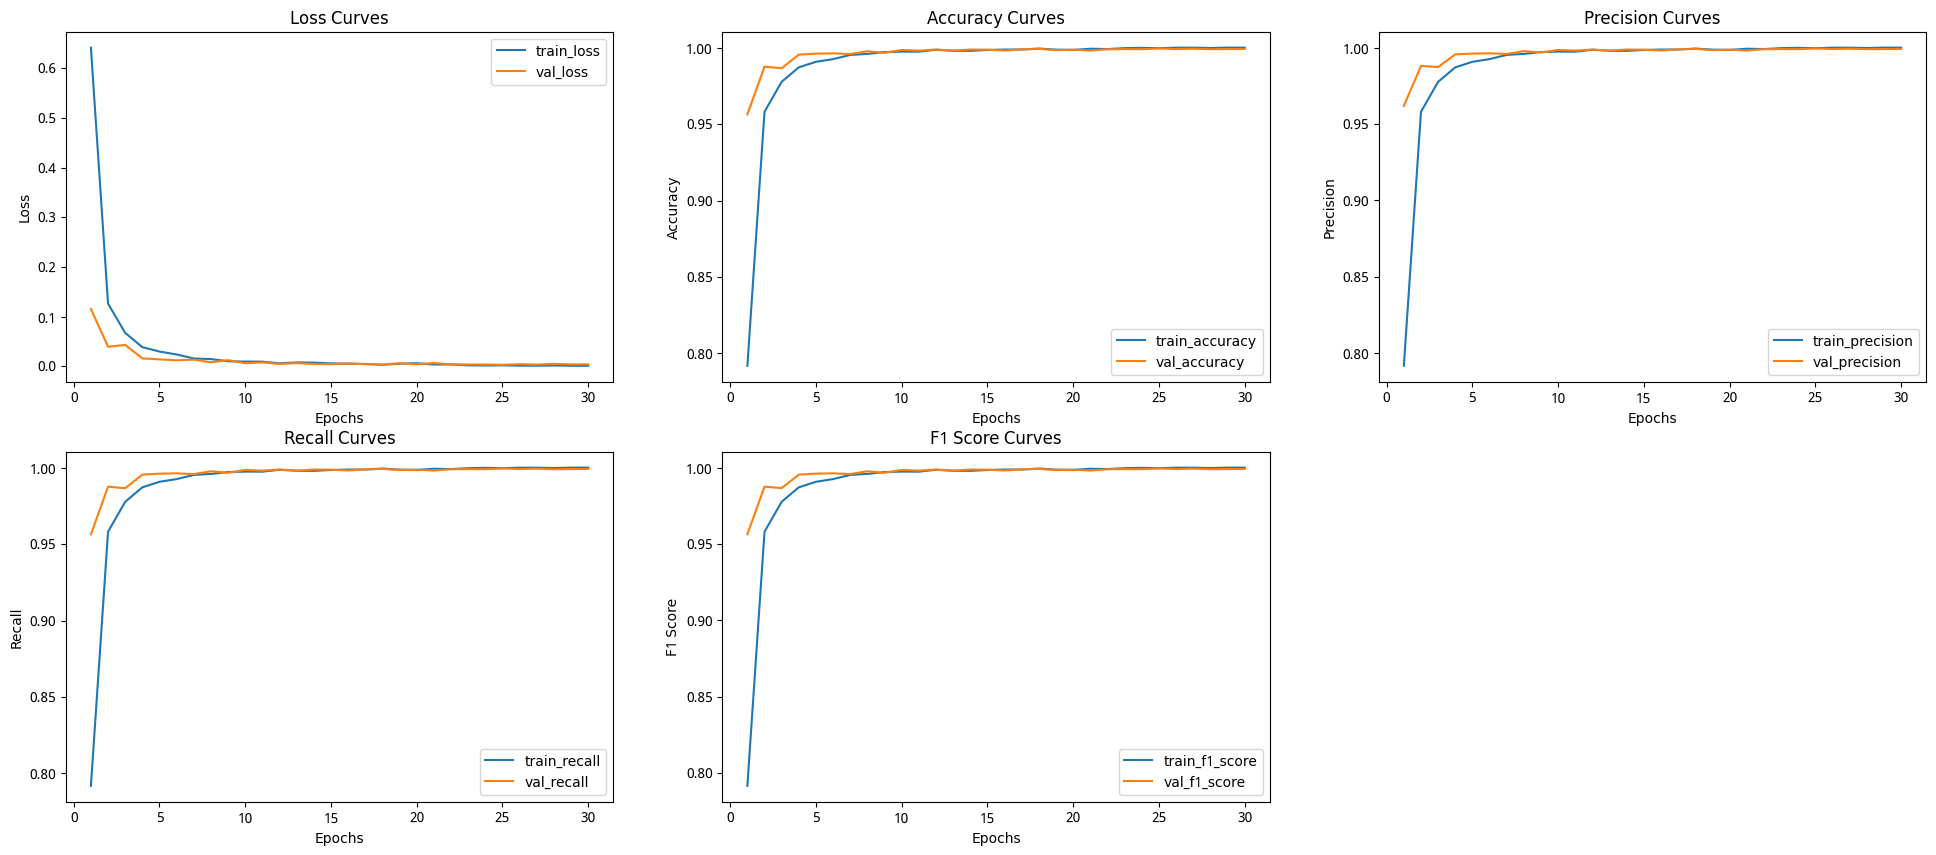

Training curves saved (no augmentation).


In [ ]:
# ============================================================
# SAVE TRAINING HISTORY (NO AUGMENTATION)
# ============================================================

history_df_no_aug = pd.DataFrame(history_no_aug)

history_df_no_aug.to_csv(
    f"{save_path_no_aug}/train_val_metrics.csv",
    index=False
)

gen_line_charts(
    data=history_df_no_aug,
    save_path=save_path_no_aug,
    plot_name="training_curves.png",
    prefix=["train_", "val_"]
)

print("Training curves saved (no augmentation).")


In [ ]:
# ============================================================
# LOAD BEST MODEL AND EVALUATE ON TEST SET (NO AUGMENTATION)
# ============================================================

best_model_no_aug = f"{save_path_no_aug}/models/best_model.pt"

model_no_aug.load_state_dict(
    torch.load(
        best_model_no_aug,
        map_location=device
    )
)

results_no_aug = detailed_evaluate(
    model_no_aug,
    test_loader_no_aug,
    class_names,
    device
)


In [ ]:
# ============================================================
# SAVE TEST RESULTS (NO AUGMENTATION)
# ============================================================

pd.DataFrame(
    [results_no_aug["metrics"]]
).to_csv(
    f"{save_path_no_aug}/test_metrics.csv",
    index=False
)

results_no_aug["report"].to_csv(
    f"{save_path_no_aug}/classification_report.csv"
)

plot_confusion_matrix(
    results_no_aug["cm"],
    class_names,
    save_path_no_aug
)

plot_misclassified(
    results_no_aug,
    class_names,
    save_path_no_aug
)

print("Evaluation complete (no augmentation).")


Evaluation complete (no augmentation).


In [ ]:
# ============================================================
# DISPLAY FINAL METRICS (NO AUGMENTATION)
# ============================================================

for key, value in results_no_aug["metrics"].items():
    print(f"{key} : {value:.4f}")


test_accuracy : 0.9989
test_precision : 0.9989
test_recall : 0.9989
test_f1_score : 0.9989


In [ ]:
# ============================================================
# SHOW CONFUSION MATRIX AND METRICS (NO AUGMENTATION)
# ============================================================

plt.figure(figsize=(20, 16))
sns.heatmap(
    results_no_aug["cm"],
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (No Augmentation)")
plt.tight_layout()
plt.show()

print("Test Metrics (No Augmentation):")
for key, value in results_no_aug["metrics"].items():
    print(f"  {key} : {value:.4f}")

print("\nClassification Report (No Augmentation):")
display(results_no_aug["report"])


In [ ]:
# ============================================================
# INITIALIZE DATA LOADERS, MODEL, AND TRAINING COMPONENTS (WITH AUGMENTATION)
# ============================================================

train_loader_aug, val_loader_aug, test_loader_aug, class_names_aug = get_dataloaders_aug()

model_aug = build_custom_cnn(num_classes=num_classes, in_channels=3).to(device)

optimizer_aug, criterion_aug, scheduler_aug = create_training_components(model_aug)

best_val_loss_aug = float("inf")

history_aug = []

save_path_aug = "./results/aug"

os.makedirs(f"{save_path_aug}/models", exist_ok=True)


Train : 35100
Validation : 10800
Test : 8100


In [ ]:
# ============================================================
# TRAIN MODEL (WITH AUGMENTATION)
# ============================================================

for epoch in range(1, epochs + 1):

    train_loss, train_preds, train_targets = train_one_epoch(
        model_aug,
        train_loader_aug,
        optimizer_aug,
        criterion_aug,
        device
    )

    train_metrics = calculate_metrics(
        train_targets,
        train_preds,
        "train_"
    )

    val_loss, val_preds, val_targets = evaluator(
        model_aug,
        val_loader_aug,
        criterion_aug,
        device
    )

    val_metrics = calculate_metrics(
        val_targets,
        val_preds,
        "val_"
    )

    scheduler_aug.step(val_loss)

    lr = optimizer_aug.param_groups[0]["lr"]

    if val_loss < best_val_loss_aug:

        best_val_loss_aug = val_loss

        torch.save(
            model_aug.state_dict(),
            f"{save_path_aug}/models/best_model.pt"
        )

        print(f"Epoch {epoch}: Best model updated")

    if epoch % 5 == 0:

        torch.save(
            model_aug.state_dict(),
            f"{save_path_aug}/models/epoch_{epoch}.pt"
        )

    history_aug.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "lr": lr,
        **train_metrics,
        **val_metrics
    })

    print(
        f"[Aug] Epoch {epoch:02d}/{epochs} | "
        f"Train Loss {train_loss:.4f} | "
        f"Val Loss {val_loss:.4f}"
    )


Epoch 1: Best model updated
[Aug] Epoch 01/30 | Train Loss 1.1173 | Val Loss 0.5017
Epoch 2: Best model updated
[Aug] Epoch 02/30 | Train Loss 0.3107 | Val Loss 0.1014
[Aug] Epoch 03/30 | Train Loss 0.1786 | Val Loss 0.1550
[Aug] Epoch 04/30 | Train Loss 0.1231 | Val Loss 0.1451
Epoch 5: Best model updated
[Aug] Epoch 05/30 | Train Loss 0.0922 | Val Loss 0.0645
Epoch 6: Best model updated
[Aug] Epoch 06/30 | Train Loss 0.0727 | Val Loss 0.0171
Epoch 7: Best model updated
[Aug] Epoch 07/30 | Train Loss 0.0620 | Val Loss 0.0118
Epoch 8: Best model updated
[Aug] Epoch 08/30 | Train Loss 0.0540 | Val Loss 0.0116
Epoch 9: Best model updated
[Aug] Epoch 09/30 | Train Loss 0.0430 | Val Loss 0.0096
Epoch 10: Best model updated
[Aug] Epoch 10/30 | Train Loss 0.0373 | Val Loss 0.0086
[Aug] Epoch 11/30 | Train Loss 0.0373 | Val Loss 0.0134
Epoch 12: Best model updated
[Aug] Epoch 12/30 | Train Loss 0.0294 | Val Loss 0.0061
[Aug] Epoch 13/30 | Train Loss 0.0273 | Val Loss 0.0074
[Aug] Epoch 14/30 

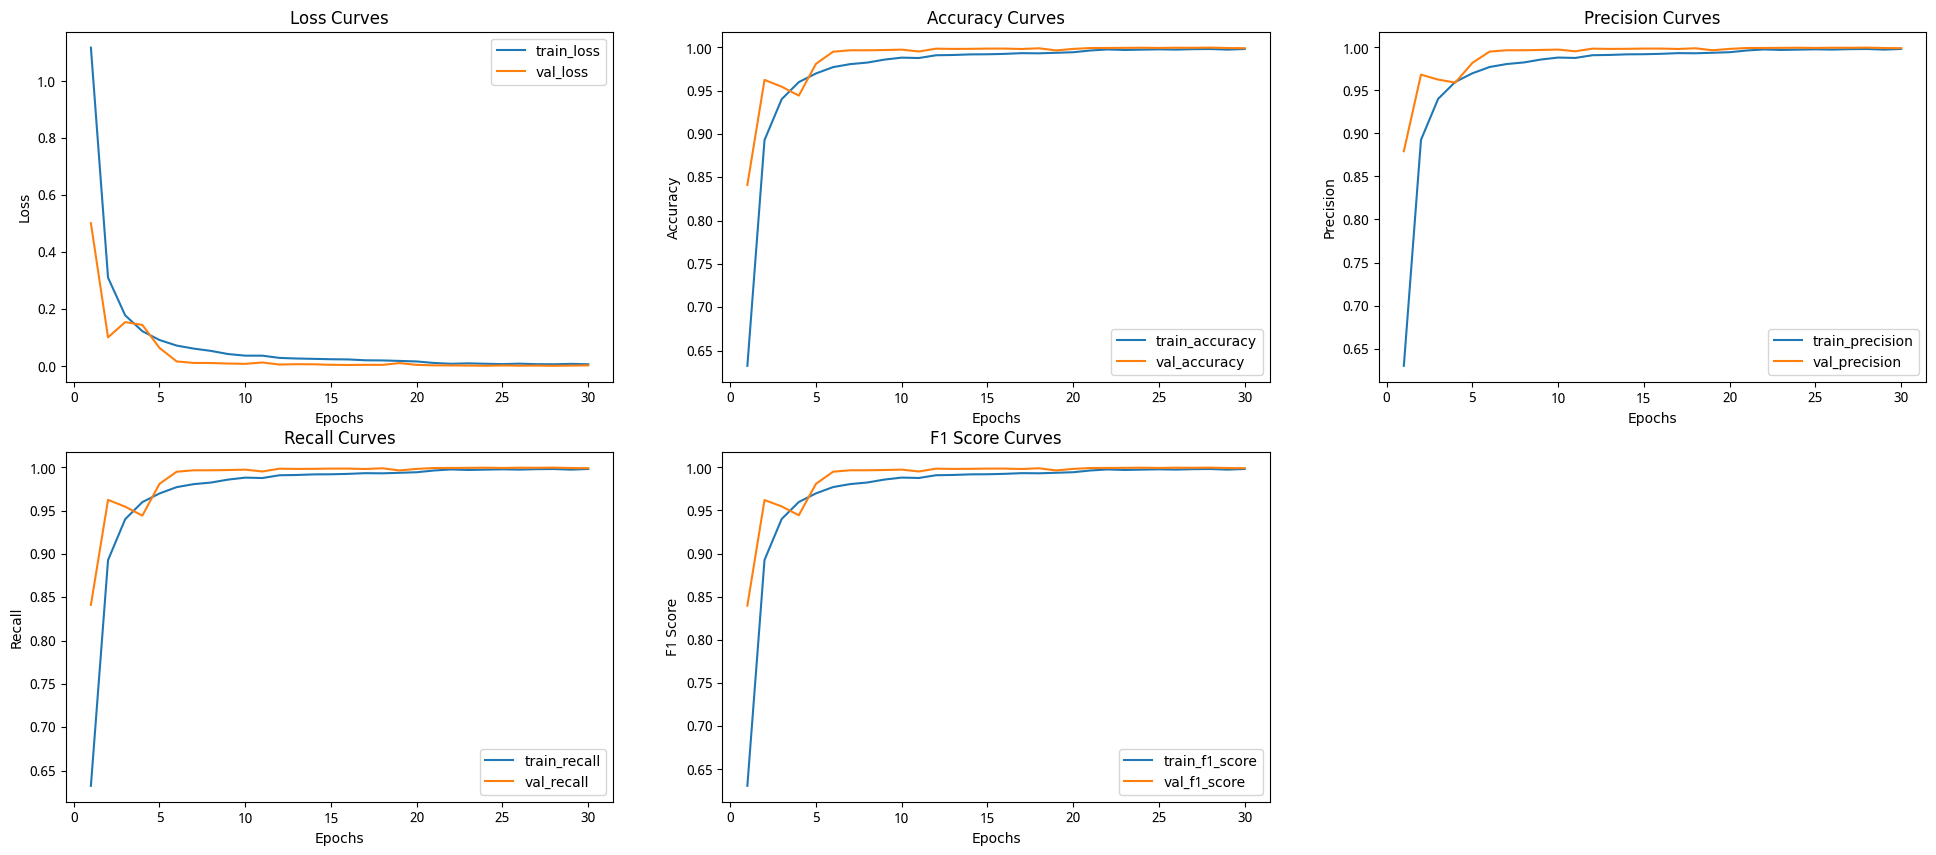

Training curves saved (with augmentation).


In [ ]:
# ============================================================
# SAVE TRAINING HISTORY (WITH AUGMENTATION)
# ============================================================

history_df_aug = pd.DataFrame(history_aug)

history_df_aug.to_csv(
    f"{save_path_aug}/train_val_metrics.csv",
    index=False
)

gen_line_charts(
    data=history_df_aug,
    save_path=save_path_aug,
    plot_name="training_curves.png",
    prefix=["train_", "val_"]
)

print("Training curves saved (with augmentation).")


In [ ]:
# ============================================================
# LOAD BEST MODEL AND EVALUATE ON TEST SET (WITH AUGMENTATION)
# ============================================================

best_model_aug = f"{save_path_aug}/models/best_model.pt"

model_aug.load_state_dict(
    torch.load(
        best_model_aug,
        map_location=device
    )
)

results_aug = detailed_evaluate(
    model_aug,
    test_loader_aug,
    class_names,
    device
)


In [ ]:
# ============================================================
# SAVE TEST RESULTS (WITH AUGMENTATION)
# ============================================================

pd.DataFrame(
    [results_aug["metrics"]]
).to_csv(
    f"{save_path_aug}/test_metrics.csv",
    index=False
)

results_aug["report"].to_csv(
    f"{save_path_aug}/classification_report.csv"
)

plot_confusion_matrix(
    results_aug["cm"],
    class_names,
    save_path_aug
)

plot_misclassified(
    results_aug,
    class_names,
    save_path_aug
)

print("Evaluation complete (with augmentation).")


Evaluation complete (with augmentation).


In [ ]:
# ============================================================
# DISPLAY FINAL METRICS (WITH AUGMENTATION)
# ============================================================

for key, value in results_aug["metrics"].items():
    print(f"{key} : {value:.4f}")


test_accuracy : 0.9995
test_precision : 0.9995
test_recall : 0.9995
test_f1_score : 0.9995


In [1]:
# ============================================================
# SHOW CONFUSION MATRIX AND METRICS (WITH AUGMENTATION)
# ============================================================

plt.figure(figsize=(20, 16))
sns.heatmap(
    results_aug["cm"],
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names_aug,
    yticklabels=class_names_aug
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (With Augmentation)")
plt.tight_layout()
plt.show()

print("Test Metrics (With Augmentation):")
for key, value in results_aug["metrics"].items():
    print(f"  {key} : {value:.4f}")

print("\nClassification Report (With Augmentation):")
display(results_aug["report"])


NameError: name 'plt' is not defined

In [ ]:
# ============================================================
# COMPARISON: NO AUGMENTATION vs WITH AUGMENTATION (TEST METRICS)
# ============================================================

comparison_df = pd.DataFrame(
    [results_no_aug["metrics"], results_aug["metrics"]],
    index=["No Augmentation", "With Augmentation"]
)

os.makedirs("./results", exist_ok=True)

comparison_df.to_csv("./results/comparison_metrics.csv")

comparison_df


,test_accuracy,test_precision,test_recall,test_f1_score
No Augmentation,0.998889,0.998893,0.998889,0.998889
With Augmentation,0.999506,0.999508,0.999506,0.999506


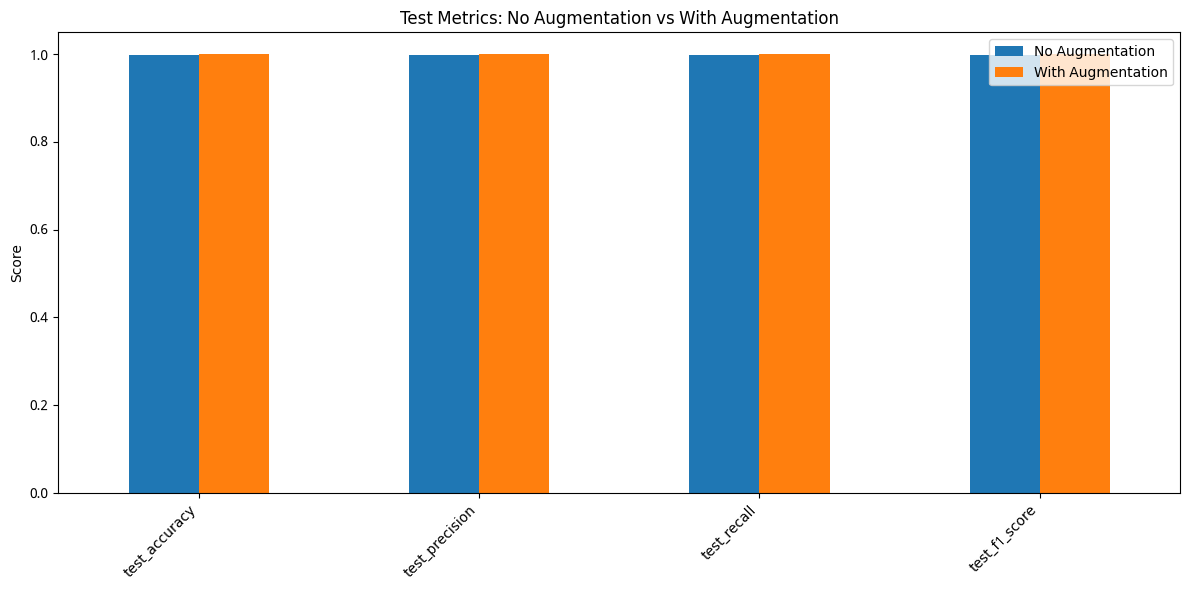

In [ ]:
# ============================================================
# COMPARISON CHART: TEST METRICS
# ============================================================

ax = comparison_df.T.plot(kind="bar", figsize=(12, 6))

plt.title("Test Metrics: No Augmentation vs With Augmentation")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.legend(title="")
plt.tight_layout()

plt.savefig("./results/comparison_metrics.png", dpi=300)

plt.show()


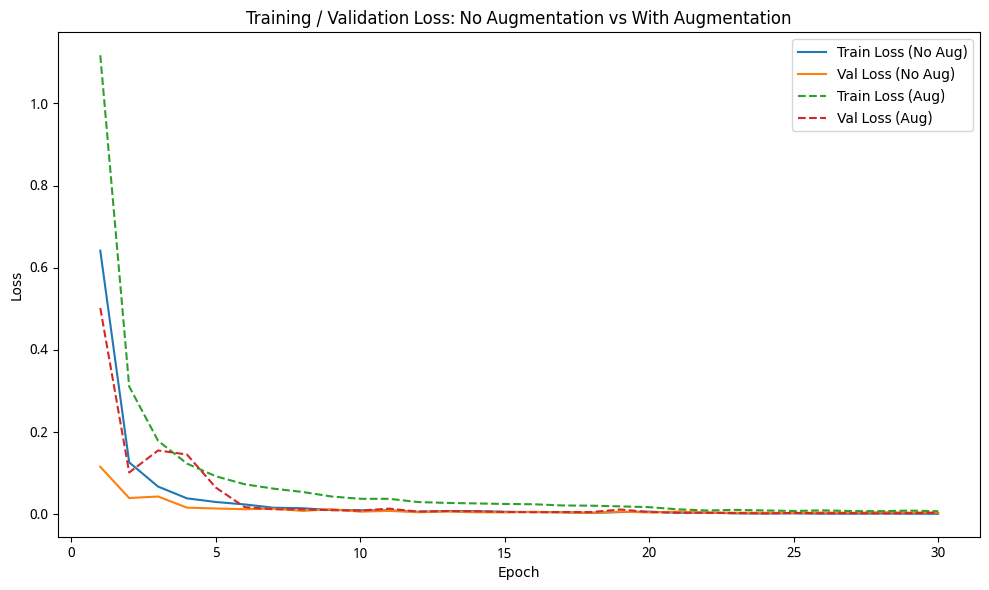

In [ ]:
# ============================================================
# COMPARISON CHART: TRAINING / VALIDATION LOSS CURVES
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(history_df_no_aug["epoch"], history_df_no_aug["train_loss"], label="Train Loss (No Aug)")
plt.plot(history_df_no_aug["epoch"], history_df_no_aug["val_loss"], label="Val Loss (No Aug)")
plt.plot(history_df_aug["epoch"], history_df_aug["train_loss"], label="Train Loss (Aug)", linestyle="--")
plt.plot(history_df_aug["epoch"], history_df_aug["val_loss"], label="Val Loss (Aug)", linestyle="--")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training / Validation Loss: No Augmentation vs With Augmentation")
plt.legend()
plt.tight_layout()

plt.savefig("./results/loss_comparison.png", dpi=300)

plt.show()


In [ ]:
# ============================================================
# SUMMARY
# ============================================================

better = comparison_df["test_accuracy"].idxmax() if "test_accuracy" in comparison_df.columns else comparison_df.iloc[:, 0].idxmax()

print(f"Best performing setup on the held-out test set: {better}")

print("\nFull comparison table:")
print(comparison_df)


Best performing setup on the held-out test set: With Augmentation

Full comparison table:
                   test_accuracy  test_precision  test_recall  test_f1_score
No Augmentation         0.998889        0.998893     0.998889       0.998889
With Augmentation       0.999506        0.999508     0.999506       0.999506
